## import necessary packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
import cv2
from tqdm.notebook import trange, tqdm
import random
from tqdm.auto import tqdm

import time

import sys, os
BASE = os.getcwd()  
if BASE not in sys.path:
    sys.path.append(BASE)

from funcs import *          
from funcs import utils      
from funcs import proj_cam_model, NetParallelTrain

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
DEVICE = 'cuda'
n_pts = 928
pattern_shape = 768
obj = 'Box'

## Pattern

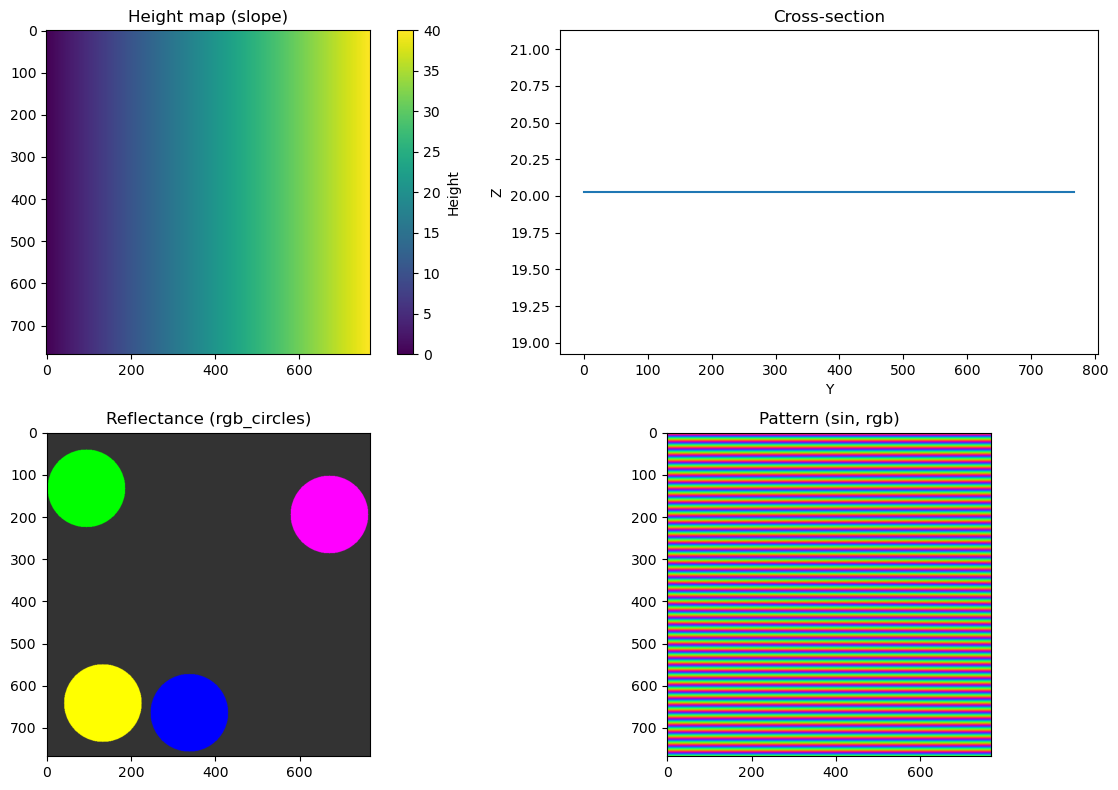

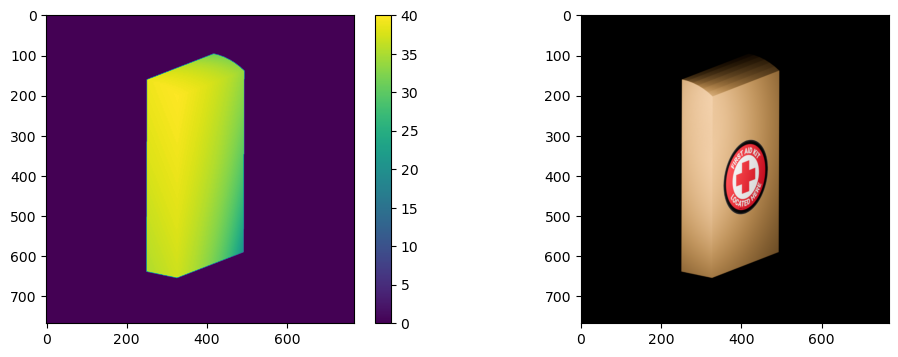

In [2]:
height_map, reflectance, pattern = generate_test_data(pattern_shape, 
                                                      # square_size = 64, 
                                                      obj_source="slope", 
                                                      pattern_source = "sin" , 
                                                      pattern_mode="rgb",
                                                      reflectance_mode="rgb_circles", 
                                                      period=16, sin_axis="y")
file_path = './Blender_test/'
relf_path = 'reflectance.png'
heig_path = 'heightmap.png'

# --- height ---
height_np = cv2.imread(file_path + heig_path, cv2.IMREAD_GRAYSCALE)  # (H,W)
height_np = cv2.resize(height_np, (n_pts, n_pts))
height_np = height_np.astype(np.float32)
height_np = (height_np / (height_np.max() + 1e-12)) * 40.0

height_map = pad_to_size(torch.from_numpy(height_np), (int(pattern_shape*1.5), int(pattern_shape*1.5))).to(torch.float32)

# cv2.resize needs numpy
height_map_np = height_map.cpu().numpy()  # (H,W), float32
height_map_np = cv2.resize(height_map_np, (pattern_shape, pattern_shape), interpolation=cv2.INTER_LINEAR)

# back to torch
height_map = torch.from_numpy(height_map_np).to(torch.float32)
# 如果后面要放 GPU：
# height_map = height_map.to(device)

# --- reflectance ---
refl_np = cv2.imread(file_path + relf_path)          # (H, W, 3), BGR, uint8
refl_np = cv2.cvtColor(refl_np, cv2.COLOR_BGR2RGB)  # (H, W, 3), RGB
refl_np = cv2.resize(refl_np, (n_pts, n_pts))
refl_np = refl_np.astype(np.float32)

# 每个 channel 一起归一化（你现在的逻辑）
refl_np = refl_np / (refl_np.max() + 1e-12)          # (H, W, 3)

# ========== padding（仍然保持 HWC） ==========
refl_pad = pad_to_size(
    torch.from_numpy(refl_np),                       # (H, W, 3)
    (int(pattern_shape * 1.5), int(pattern_shape * 1.5))
).numpy()                                            # (H2, W2, 3)

# ========== resize（OpenCV 只认 HWC） ==========
refl_pad = cv2.resize(
    refl_pad,
    (pattern_shape, pattern_shape),
    interpolation=cv2.INTER_LINEAR
)                                                    # (H, W, 3)

# ========== back to torch, channel-first ==========
reflectance = torch.from_numpy(refl_pad) \
    .permute(2, 0, 1) \
    .to(torch.float32)                               # (3, H, W)


# height_map = torch.rot90(height_map, k = 2,dims = (0,1))/height_map.max()*100
plt.figure(figsize = (12,4))
plt.subplot(121)
plt.imshow(height_map)
plt.colorbar()
plt.subplot(122)
plt.imshow(reflectance.permute(1,2,0))
plt.show()

In [3]:
calib_results = utils.json_loader(file_path=f'./Real_data/{obj}/{obj}_final_calibration_summary.json')
cam_COP = calib_results['camera_position_world']
cam_R = calib_results['R_world_to_camera']
cam_K = calib_results['camera_intrinsic']
proj_COP = calib_results['projector_position_world']
proj_R = calib_results['R_world_to_projector']
proj_K = calib_results['projector_intrinsic']

Projector focal (fx, fy): (2405.9962372020145, 2503.0073079538874)
Projector principal point offset (Δx, Δy): (13.869208331625885, 261.2089887642941)
Camera focal (fx, fy): (4550.583332930169, 4560.969653462267)
Camera principal point offset (Δx, Δy): (62.9898496654705, -70.75718807479461)


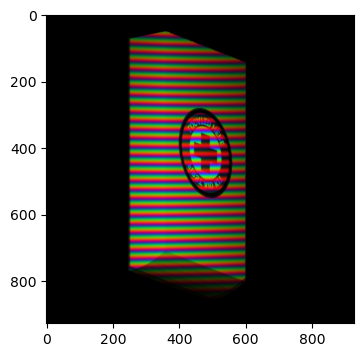

In [4]:
proj_t = -proj_R @ proj_COP
cam_t = -cam_R @ cam_COP


cam_res = (n_pts, n_pts)   
proj_res = (pattern_shape, pattern_shape)  

intrinsics_para = parse_intrinsics(cam_K, proj_K, cam_res, proj_res)

print("Projector focal (fx, fy):", intrinsics_para["projector"]["focal"])
print("Projector principal point offset (Δx, Δy):", intrinsics_para["projector"]["offset"])
print("Camera focal (fx, fy):", intrinsics_para["camera"]["focal"])
print("Camera principal point offset (Δx, Δy):", intrinsics_para["camera"]["offset"])


proj_sensor_size = min(proj_res)
proj_fx, proj_fy = intrinsics_para["projector"]["focal"]   # (fx, fy)
proj_cx_px, proj_cy_px = intrinsics_para["projector"]["offset"]

cam_sensor_size = min(cam_res)
cam_fx,  cam_fy  = intrinsics_para["camera"]["focal"]      # (fx, fy)
cam_cx_px, cam_cy_px = intrinsics_para["camera"]["offset"]
     
    
extent_mm = [-200, 200, -200, 200]   

# Plane coefficients
A = 0.014215
B = 0.008262
C =  0.999865
D = 0.949929

# Extent in mm
xmin, xmax, ymin, ymax = extent_mm

# Resolution
num = proj_res  # 

# Create meshgrid (PyTorch)
x = torch.linspace(xmin, xmax, num[0])
y = torch.linspace(ymin, ymax, num[1])

X, Y = torch.meshgrid(x, y, indexing="xy")  

# Compute Z(x,y)
height_map_whiteboard = -(A * X + B * Y + D) / C

# cam_resolution = 3036
cam_resolution = n_pts
num_photons = None

measured_img = torch.zeros((pattern.shape[0], n_pts, n_pts))[None,:,:,:].to(DEVICE)
# reflectance = torch.ones_like(pattern)
for pattern_c in range(pattern.shape[0]):
    pattern_proj = pattern[pattern_c,:,:]
    imager2 = Proj_Cam_model(
        proj_f=(proj_fx, proj_fy),
        cam_f=(cam_fx, cam_fy),

        proj_sensor_w_px=proj_sensor_size,
        proj_sensor_h_px=proj_sensor_size,
        cam_sensor_px=cam_sensor_size,

        proj_R=proj_R, proj_t=proj_t,
        cam_R=cam_R, cam_t=cam_t,

        proj_cx_px=proj_cx_px ,
        proj_cy_px=proj_cy_px ,
        cam_cx_px=cam_cx_px,
        cam_cy_px=cam_cy_px,

        device=DEVICE
    )
    measured_img2 = imager2.render(height_map, reflectance[pattern_c,:,:], pattern_proj,
                                   extent_mm=extent_mm,
                                   photon_count=num_photons, show=0, print_matrix= 0,
                                   cam_res=(cam_resolution, cam_resolution))
    measured_img[0,pattern_c,:,:] = measured_img2.squeeze()

# imager2.plot_geometry(axis_length = 150)
plt.figure(figsize = (4,4))
# plt.subplot(121)
plt.imshow(measured_img.squeeze().permute(1,2,0).cpu())
# plt.subplot(122)
# plt.imshow(pattern_on_whiteboard.permute(1,2,0).cpu())
plt.show()

# plt.imshow(torch.abs(rgb_to_gray_tensor(pattern_on_whiteboard).permute(1,2,0).cpu())-rgb_to_gray_tensor(measured_img).squeeze(0).permute(1,2,0).cpu())
# plt.colorbar()
# plt.show()

## Network

In [5]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

[1/4159] net0: 8.087e-02


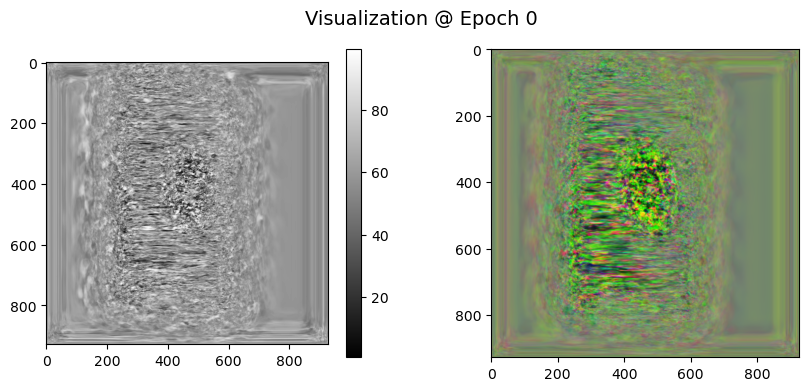

[101/4159] net0: 1.284e-03


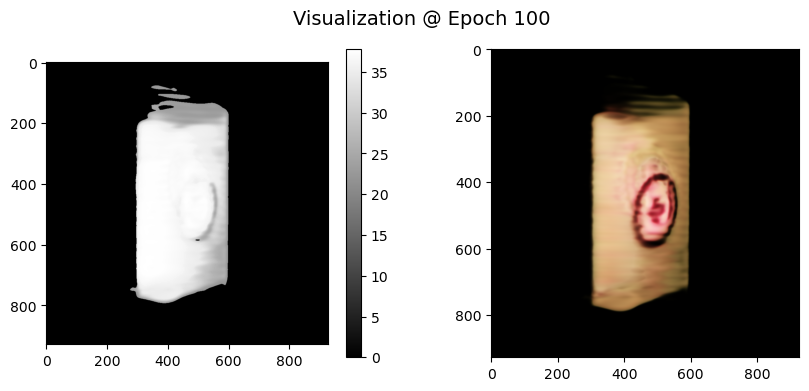

[201/4159] net0: 2.440e-03


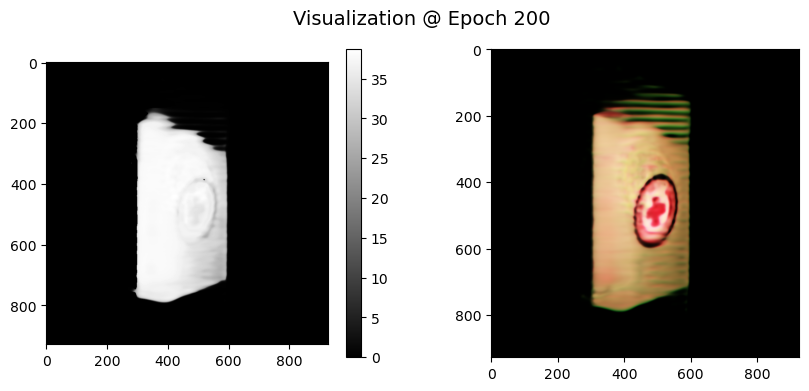

[301/4159] net0: 3.345e-03


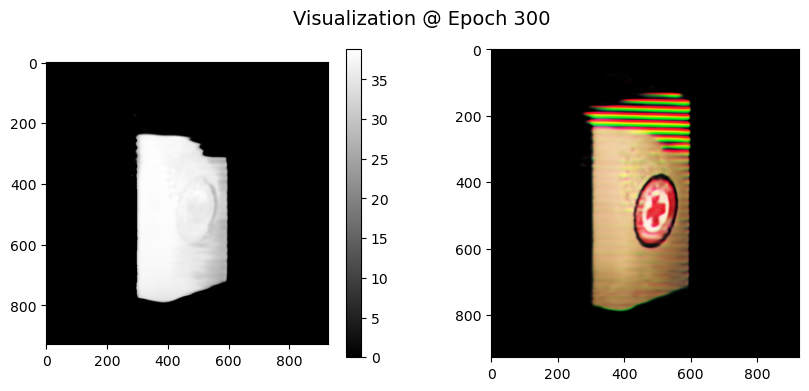

[401/4159] net0: 4.548e-03


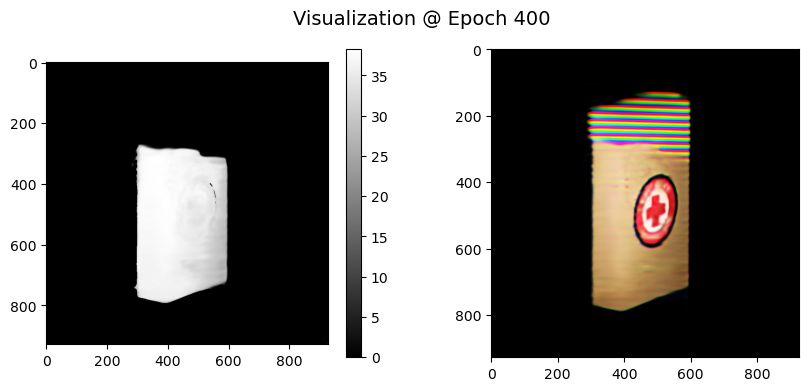

[601/4159] net0: 4.433e-03


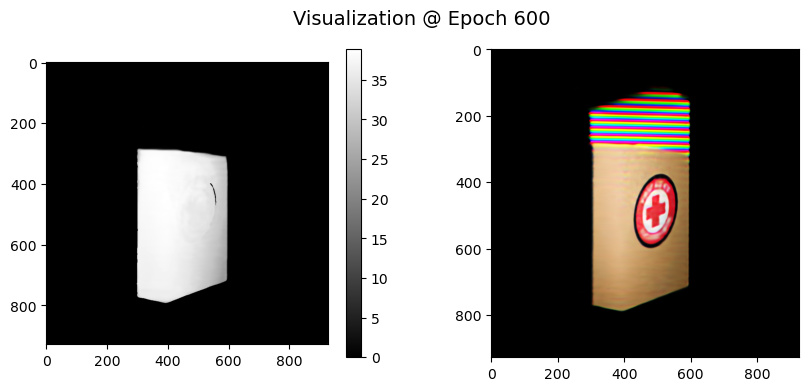

[701/4159] net0: 4.505e-03


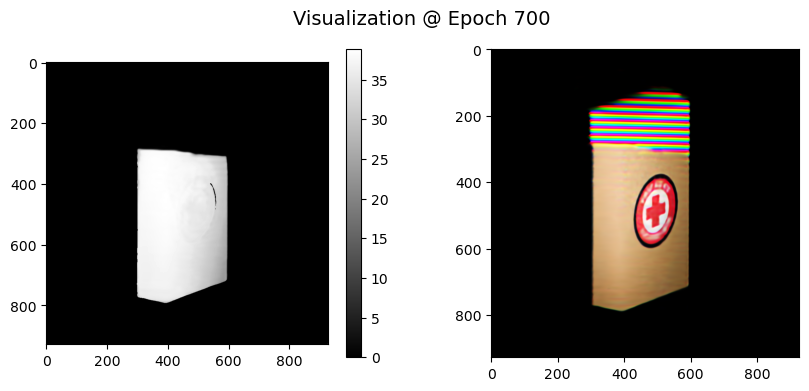

[801/4159] net0: 4.500e-03


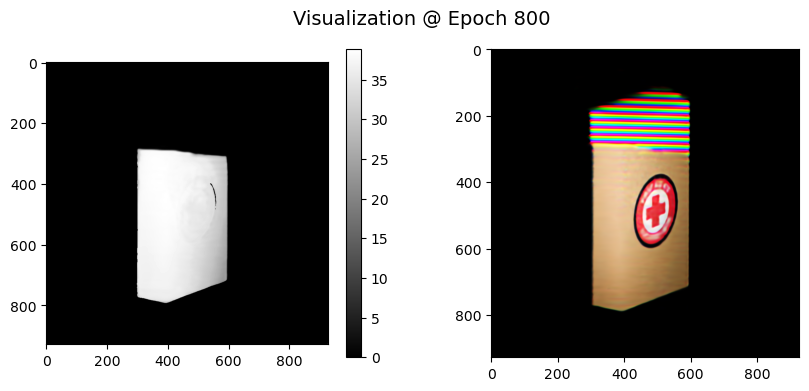

[901/4159] net0: 4.502e-03


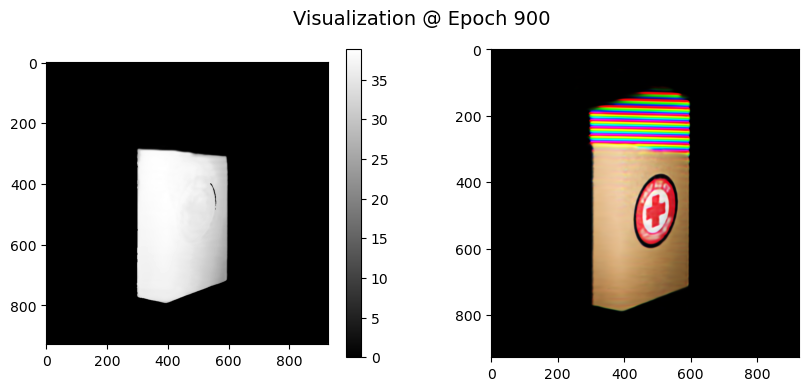

[1001/4159] net0: 4.447e-03


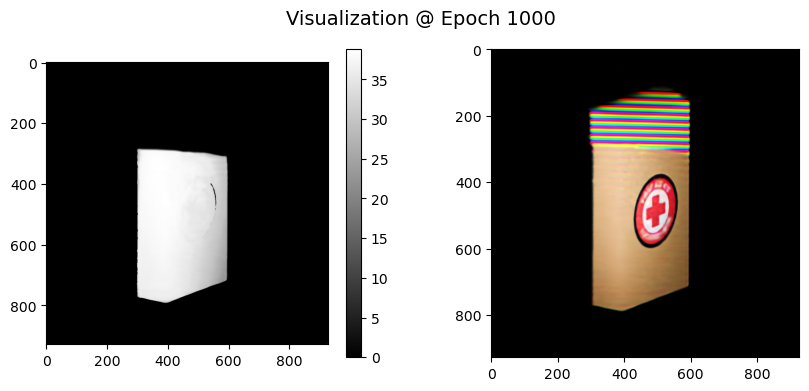

[1101/4159] net0: 4.421e-03


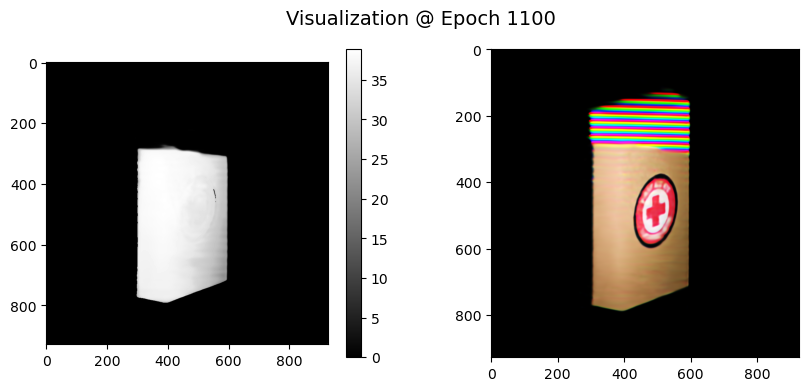

[1201/4159] net0: 4.819e-03


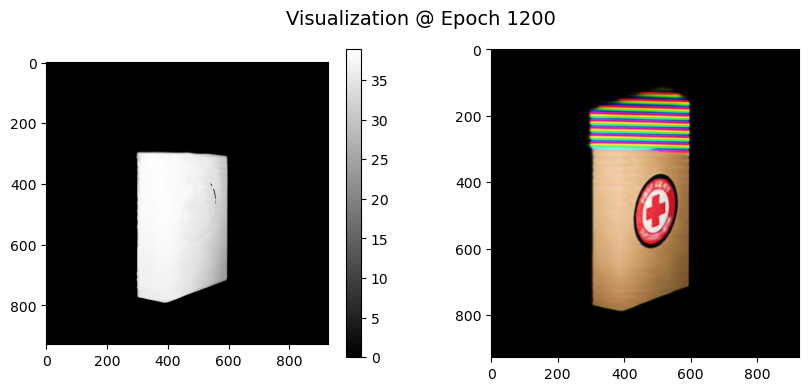

[1301/4159] net0: 4.761e-03


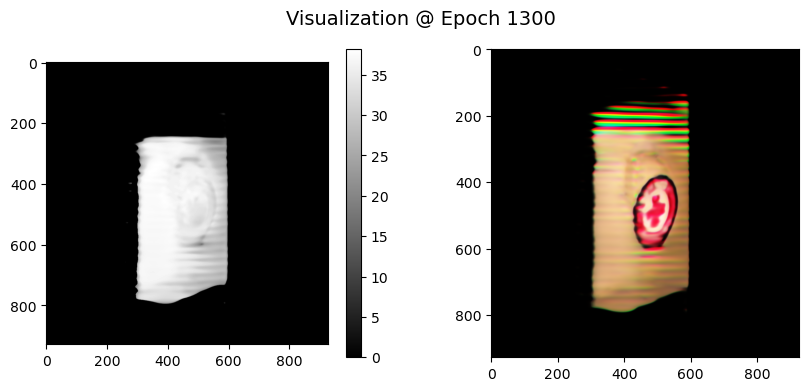

[1401/4159] net0: 4.092e-03


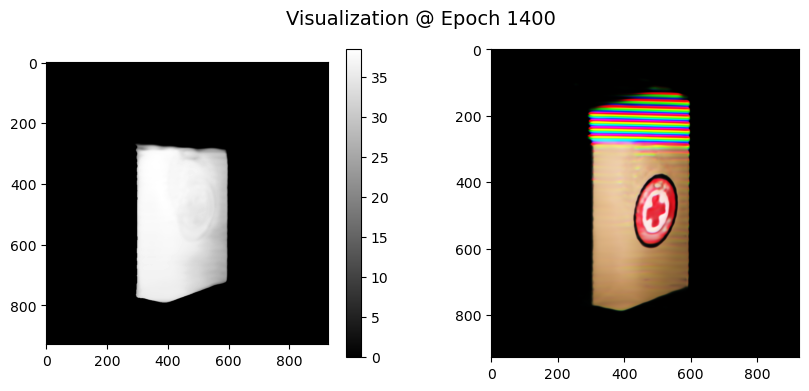

[1501/4159] net0: 4.344e-03


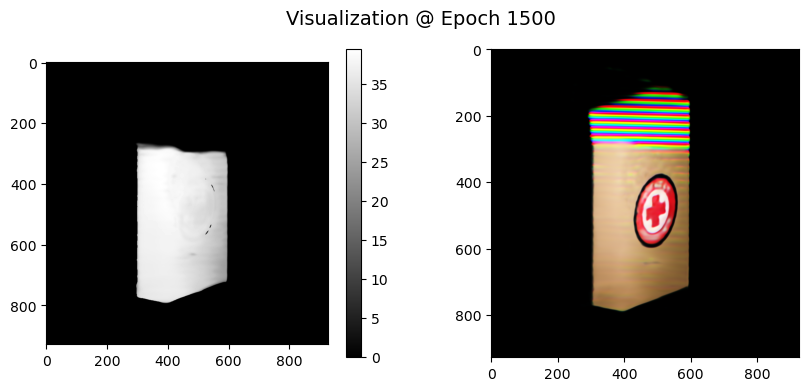

[1601/4159] net0: 4.166e-03


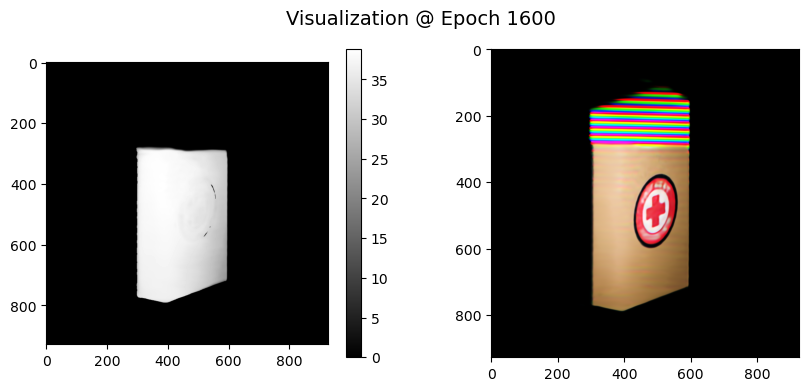

[1701/4159] net0: 4.302e-03


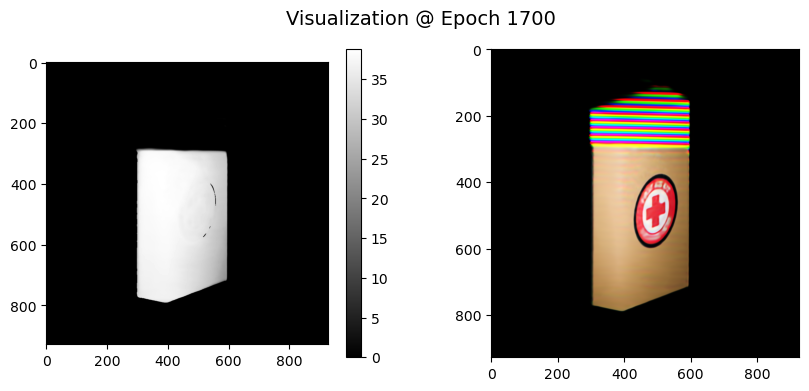

[1801/4159] net0: 4.435e-03


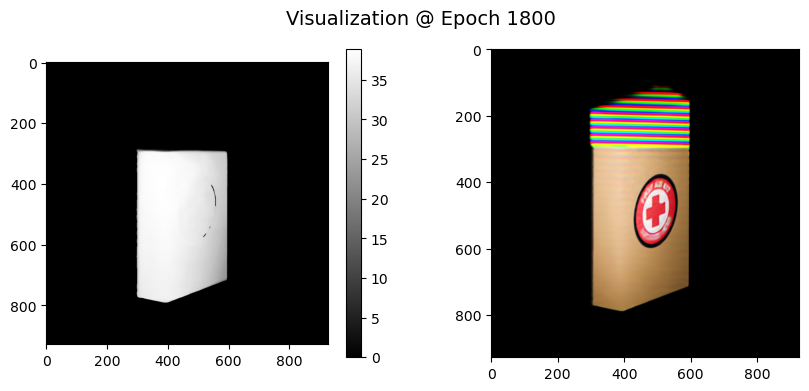

[1901/4159] net0: 4.371e-03


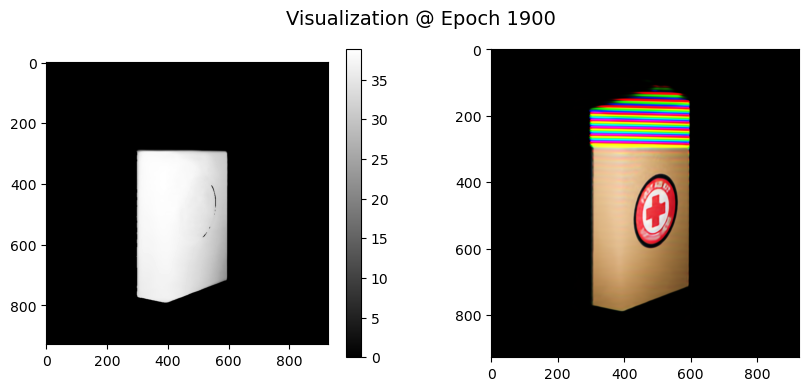

[2001/4159] net0: 4.421e-03


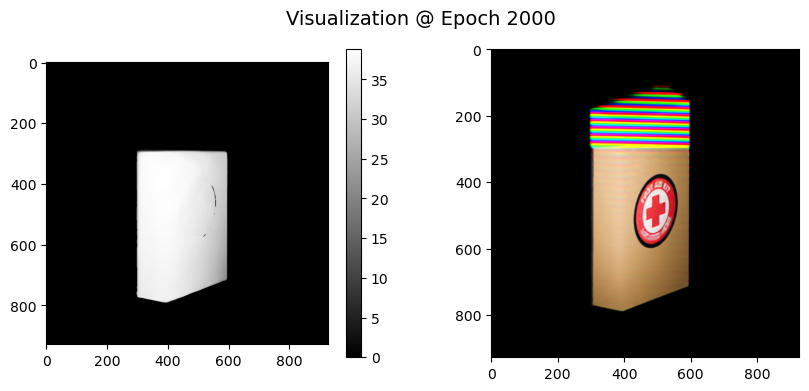

[2101/4159] net0: 4.355e-03


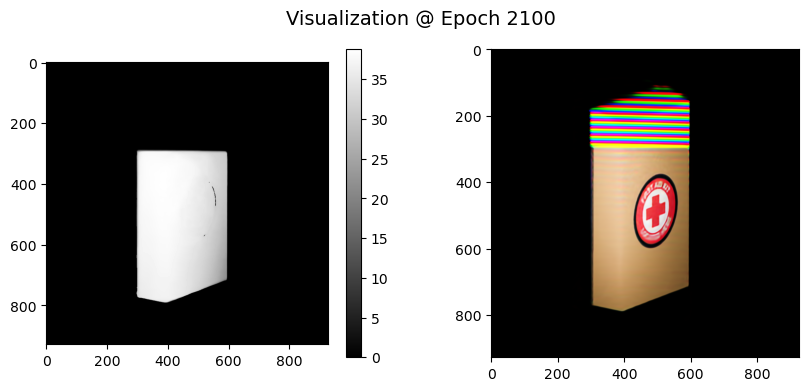

[2201/4159] net0: 4.384e-03


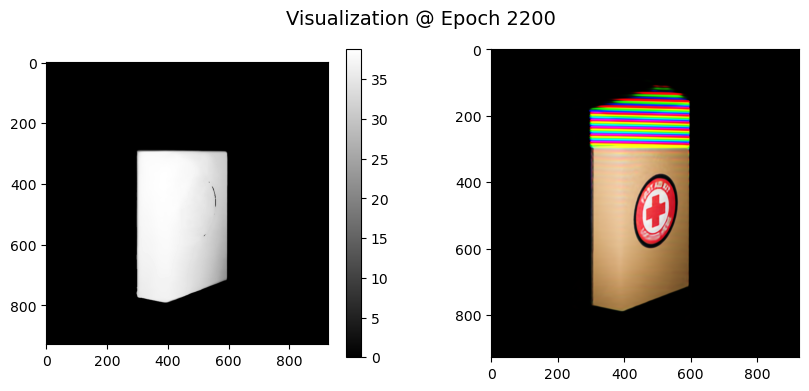

[2301/4159] net0: 4.379e-03


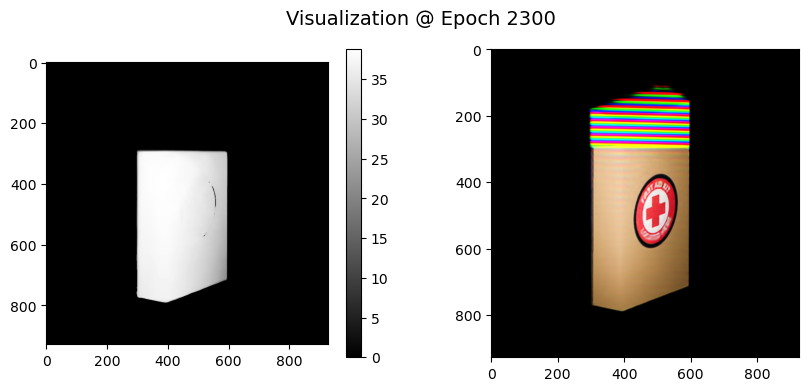

[2401/4159] net0: 4.377e-03


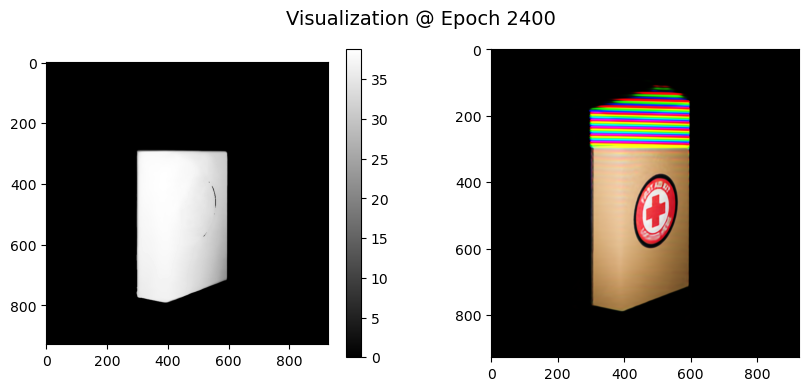

[2501/4159] net0: 4.376e-03


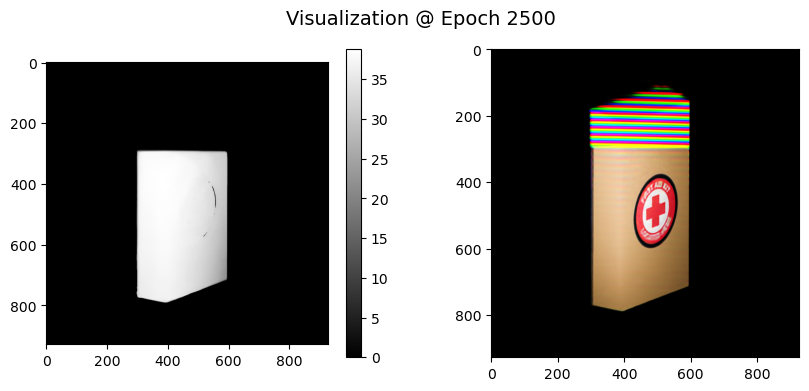

[2601/4159] net0: 4.374e-03


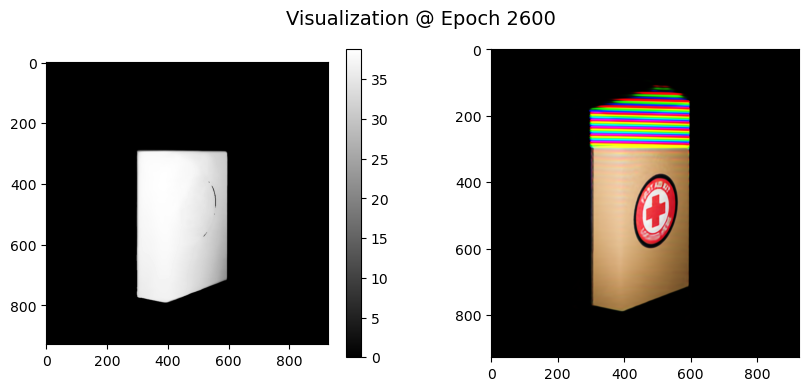

[2701/4159] net0: 4.339e-03


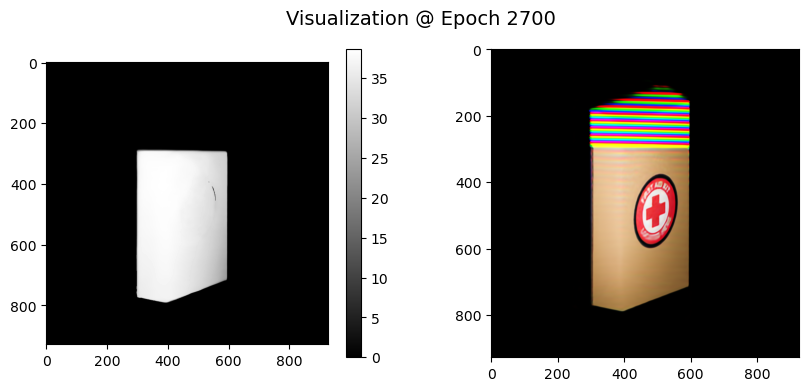

In [ ]:
proj_img_sys = imager2

output_root = './NN_train_results/' 
os.makedirs(output_root, exist_ok=True)
n_nets = 1

seeds = [42]
for seed in seeds:
    setup_seed(seed)
    # ========== ==========
    model = MultiChannelFusionNet(in_channels=3, base_channels=64).to(DEVICE)

    ParallelTrain = NetParallelTrain(base_model=model, n_nets=1, device=DEVICE)


    multi_model, loss_lists = ParallelTrain.train(
        measured_img=measured_img,
        proj_img_sys=proj_img_sys,
        pattern=pattern,
        extent_mm=extent_mm,
        num_epochs=int(3199*1.3+1),
        show_every=100,
        use_height_smooth=1,
        use_reflectance_smooth=0,
        msk_on=0,

        snapshot_every=None,
        snapshot_root=f'{output_root}/{seed}/',
    )


In [8]:
num_para = count_parameters(multi_model)
print(f'model parameters:{num_para}')

model parameters:75163684
